# 🏷️ Hybrid Labeling — Sentiment Analysis Blu by BCA Digital

Notebook ini mengimplementasikan **hybrid labeling strategy** yang menggabungkan:
- Rating ekstrem (1-2 dan 4-5) → langsung dipercaya sebagai ground truth
- Rating 3 → difilter berdasarkan konten teks (panjang, kata kunci sentimen)
- Konflik teks vs rating → di-drop untuk menghindari noise

**Output:** Dataset berlabel bersih siap untuk modeling

## 1. Import Library

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

## 2. Load Data

In [11]:
# ============================================================
# Sesuaikan path dengan file output preprocessing kamu
# ============================================================
INPUT_PATH  = '../data/bluapp_reviews_preprocessed.csv'   # ← output dari preprocessing
OUTPUT_PATH = '../data/bluapp_reviews_labeled.csv'  # ← output notebook ini

SCORE_COL   = 'score'         # kolom rating bintang (1-5)
TEXT_COL    = 'final_content'  # kolom teks yang sudah dipreprocessing
RAW_COL     = 'content'       # kolom teks asli (sebelum preprocessing)

df = pd.read_csv(INPUT_PATH)
print(f'Data dimuat: {df.shape[0]:,} baris, {df.shape[1]} kolom')
print(f'Kolom: {df.columns.tolist()}')
df.head(3)

Data dimuat: 26,157 baris, 7 kolom
Kolom: ['content', 'score', 'at', 'thumbsUpCount', 'replyContent', 'final_content', 'tokens_stemmed']


,content,score,at,thumbsUpCount,replyContent,final_content,tokens_stemmed
0,"verifikasi wajah tidak jelas,stuck di pastikan...",1,2026-05-16 23:08:41,0,"Hai, Kak Darma. Maaf atas ketidaknyamanannya. ...",verifikasi wajah jelastuck pasti hp gerak hp t...,"['verifikasi', 'wajah', 'jelastuck', 'pasti', ..."
1,hihihihi kog ngeri nian baca review penggunany...,1,2026-05-16 22:10:32,0,"Hai, Kak Maulana. Maaf atas ketidaknyamanannya...",hihihihi kog ngeri nian baca review guna horor...,"['hihihihi', 'kog', 'ngeri', 'nian', 'baca', '..."
2,gak perlu di instal hanya menghabiskan paket d...,1,2026-05-16 21:52:46,0,"Hai, Kak Jaki. Maaf atas ketidaknyamanannya. K...",instal habis paket data cuk,"['instal', 'habis', 'paket', 'data', 'cuk']"


In [12]:
# Cek distribusi rating awal
print('Distribusi rating awal:')
rating_dist = df[SCORE_COL].value_counts().sort_index()
for r, c in rating_dist.items():
    bar = '█' * int(c / rating_dist.max() * 30)
    print(f'  {r}⭐  {bar}  {c:,} ({c/len(df)*100:.1f}%)')

print(f'\nTotal review: {len(df):,}')

Distribusi rating awal:
  1⭐  ████████████  6,121 (23.4%)
  2⭐  ███  1,501 (5.7%)
  3⭐  ███  1,801 (6.9%)
  4⭐  ███  1,968 (7.5%)
  5⭐  ██████████████████████████████  14,766 (56.5%)

Total review: 26,157


## 3. Kamus Kata Kunci Sentimen Bahasa Indonesia

Digunakan untuk membantu klasifikasi rating 3 yang ambigu.

In [13]:
# ============================================================
# Kamus kata kunci sentimen — konteks aplikasi mobile banking
# Bisa kamu tambah / edit sesuai dataset kamu
# ============================================================

POSITIVE_WORDS = [
    # Pujian umum
    'bagus', 'baik', 'keren', 'mantap', 'mantul', 'oke', 'ok',
    'canggih', 'hebat', 'luar biasa', 'top', 'terbaik', 'sempurna',
    'suka', 'senang', 'puas', 'memuaskan', 'recommended', 'rekomen',
    'mudah', 'gampang', 'praktis', 'nyaman', 'lancar', 'cepat',
    'ringan', 'stabil', 'aman', 'terpercaya', 'membantu', 'berguna',
    'bermanfaat', 'worth', 'worth it', 'terima kasih', 'makasih',
    'sukses', 'berhasil', 'jalan', 'work', 'works', 'berjalan',
    'update bagus', 'makin bagus', 'makin keren', 'semakin baik',
    'fitur lengkap', 'fitur bagus', 'user friendly', 'mudah digunakan',
    'tampilan bagus', 'tampilan keren', 'desain bagus',
    # Ungkapan informal positif
    'gas', 'gass', 'niceee', 'nice', 'good', 'great', 'excellent',
    'best', 'perfect', 'smooth', 'responsive', 'helpful',
]

NEGATIVE_WORDS = [
    # Keluhan umum
    'error', 'eror', 'bug', 'crash', 'hang', 'lemot', 'lambat', 'lama',
    'loading', 'lag', 'lagg', 'lelet', 'lemot', 'berat',
    'gagal', 'tidak bisa', 'gabisa', 'ga bisa', 'gak bisa', 'ngak bisa',
    'tidak berhasil', 'tidak berjalan', 'tidak jalan',
    'susah', 'sulit', 'ribet', 'rumit', 'membingungkan', 'bingung',
    'jelek', 'buruk', 'parah', 'payah', 'kacau', 'berantakan',
    'menyebalkan', 'kesel', 'kesal', 'marah', 'kecewa', 'mengecewakan',
    'tidak puas', 'ga puas', 'gak puas', 'tidak memuaskan',
    'tidak recommended', 'tidak rekomen', 'jangan', 'hindari',
    'uninstall', 'hapus', 'buang', 'delete',
    # Keluhan spesifik banking
    'transfer gagal', 'tidak bisa transfer', 'transaksi gagal',
    'tidak bisa login', 'login gagal', 'tidak bisa masuk',
    'saldo tidak', 'saldo salah', 'saldo berkurang',
    'otp tidak', 'otp gagal', 'kode otp', 'verifikasi gagal',
    'tidak bisa top up', 'top up gagal',
    'aplikasi force close', 'keluar sendiri', 'mati sendiri',
    # Ungkapan informal negatif
    'nyebelin', 'bikin kesel', 'bikin emosi', 'bikin kesal',
    'boros', 'menguras', 'rugi', 'tipu', 'bohong',
    'worst', 'terrible', 'horrible', 'awful', 'useless', 'broken',
    'not working', 'doesnt work',
]

# Kata yang membatalkan sentimen positif (negasi)
NEGATION_WORDS = [
    'tidak', 'ga', 'gak', 'ngak', 'nggak', 'bukan', 'belum',
    'kurang', 'jarang', 'susah', 'sulit',
]

print(f'Kata positif  : {len(POSITIVE_WORDS)} entri')
print(f'Kata negatif  : {len(NEGATIVE_WORDS)} entri')
print(f'Kata negasi   : {len(NEGATION_WORDS)} entri')

Kata positif  : 65 entri
Kata negatif  : 88 entri
Kata negasi   : 11 entri


## 4. Fungsi Pendeteksi Sentimen dari Teks

In [14]:
def count_sentiment_words(text: str) -> dict:
    """
    Hitung skor sentimen dari teks berdasarkan kamus kata kunci.
    Menangani negasi sederhana (mis: 'tidak bagus' → negatif).

    Returns dict:
        pos_count   : jumlah kata positif ditemukan
        neg_count   : jumlah kata negatif ditemukan
        net_score   : pos_count - neg_count
        text_label  : 'positif' / 'negatif' / 'netral'
    """
    if not isinstance(text, str) or len(text.strip()) == 0:
        return {'pos_count': 0, 'neg_count': 0, 'net_score': 0, 'text_label': 'netral'}

    text_lower = text.lower()
    words      = text_lower.split()
    pos_count  = 0
    neg_count  = 0

    # Cek kata positif — dengan deteksi negasi pada 2 kata sebelumnya
    for phrase in POSITIVE_WORDS:
        if phrase in text_lower:
            idx = text_lower.find(phrase)
            pre_words = text_lower[:idx].split()[-2:]  # 2 kata sebelum
            if any(neg in pre_words for neg in NEGATION_WORDS):
                neg_count += 1   # negasi balik jadi negatif
            else:
                pos_count += 1

    # Cek kata negatif
    for phrase in NEGATIVE_WORDS:
        if phrase in text_lower:
            neg_count += 1

    net_score = pos_count - neg_count

    if net_score > 0:
        text_label = 'positif'
    elif net_score < 0:
        text_label = 'negatif'
    else:
        text_label = 'netral'

    return {
        'pos_count' : pos_count,
        'neg_count' : neg_count,
        'net_score' : net_score,
        'text_label': text_label,
    }


def get_rating_label(score: int) -> str:
    """Konversi rating bintang ke label sentimen."""
    if score >= 4: return 'positif'
    if score == 3: return 'netral'
    return 'negatif'


# Tes cepat
test_cases = [
    'aplikasi bagus dan mudah digunakan',
    'sering error tidak bisa login',
    'tidak bagus sama sekali',   # negasi
    'lumayan',                   # ambigu
]
print('Tes fungsi:\n')
for t in test_cases:
    r = count_sentiment_words(t)
    print(f'  "{t}"')
    print(f'   → pos:{r["pos_count"]} neg:{r["neg_count"]} skor:{r["net_score"]} label:{r["text_label"]}\n')

Tes fungsi:

  "aplikasi bagus dan mudah digunakan"
   → pos:3 neg:0 skor:3 label:positif

  "sering error tidak bisa login"
   → pos:0 neg:3 skor:-3 label:negatif

  "tidak bagus sama sekali"
   → pos:0 neg:1 skor:-1 label:negatif

  "lumayan"
   → pos:0 neg:0 skor:0 label:netral



## 5. Hybrid Labeling Pipeline

In [15]:
# ============================================================
# PARAMETER — bisa kamu tuning
# ============================================================
MIN_TEXT_LEN_WORDS  = 3   # teks < N kata dianggap terlalu pendek
RATING3_MIN_WORDS   = 8   # rating 3 butuh teks min N kata agar dipercaya
CONFLICT_THRESHOLD  = 2   # selisih pos-neg yang dianggap 'konflik kuat'

print('Parameter hybrid labeling:')
print(f'  MIN_TEXT_LEN_WORDS  = {MIN_TEXT_LEN_WORDS}')
print(f'  RATING3_MIN_WORDS   = {RATING3_MIN_WORDS}')
print(f'  CONFLICT_THRESHOLD  = {CONFLICT_THRESHOLD}')

Parameter hybrid labeling:
  MIN_TEXT_LEN_WORDS  = 3
  RATING3_MIN_WORDS   = 8
  CONFLICT_THRESHOLD  = 2


In [16]:
def hybrid_label(row) -> dict:
    """
    Strategi hybrid labeling:

    Rating 1-2  → NEGATIF langsung (rating ekstrem = dipercaya)
    Rating 4-5  → POSITIF langsung (rating ekstrem = dipercaya)
                  *kecuali* teks sangat kuat berlawanan (konflik)

    Rating 3    → ambil dari teks jika teks panjang dan jelas
                  drop jika teks terlalu pendek atau ambigu

    Returns:
        label   : 'positif' / 'negatif' / 'netral'
        method  : cara labeling ('rating', 'teks', 'hybrid', 'drop')
        reason  : penjelasan singkat
    """
    score       = row[SCORE_COL]
    text        = str(row.get(TEXT_COL, ''))
    word_count  = len(text.split())
    sent        = count_sentiment_words(text)
    rating_lbl  = get_rating_label(score)

    # ── Teks terlalu pendek → pakai rating saja
    if word_count < MIN_TEXT_LEN_WORDS:
        if score == 3:
            return {'label': 'drop', 'method': 'drop',
                    'reason': 'rating3_teks_terlalu_pendek'}
        return {'label': rating_lbl, 'method': 'rating',
                'reason': 'teks_pendek_pakai_rating'}

    # ── Rating 1-2: negatif kuat
    if score <= 2:
        # Konflik: rating negatif tapi teks sangat positif (jarang, tapi ada)
        if sent['net_score'] >= CONFLICT_THRESHOLD and sent['neg_count'] == 0:
            return {'label': 'drop', 'method': 'drop',
                    'reason': 'konflik_rating_rendah_teks_positif'}
        return {'label': 'negatif', 'method': 'rating',
                'reason': 'rating_ekstrem_rendah'}

    # ── Rating 4-5: positif kuat
    if score >= 4:
        # Konflik: rating tinggi tapi teks sangat negatif
        if sent['net_score'] <= -CONFLICT_THRESHOLD and sent['pos_count'] == 0:
            return {'label': 'drop', 'method': 'drop',
                    'reason': 'konflik_rating_tinggi_teks_negatif'}
        return {'label': 'positif', 'method': 'rating',
                'reason': 'rating_ekstrem_tinggi'}

    # ── Rating 3: netral ambigu — andalkan teks
    assert score == 3

    # Teks kurang panjang untuk dipercaya
    if word_count < RATING3_MIN_WORDS:
        return {'label': 'drop', 'method': 'drop',
                'reason': 'rating3_teks_pendek'}

    # Teks tidak memiliki sinyal sentimen jelas
    if sent['pos_count'] == 0 and sent['neg_count'] == 0:
        return {'label': 'drop', 'method': 'drop',
                'reason': 'rating3_tidak_ada_sinyal'}

    # Teks ambigu (sama-sama pos dan neg)
    if sent['pos_count'] > 0 and sent['neg_count'] > 0 and abs(sent['net_score']) < 2:
        return {'label': 'netral', 'method': 'teks',
                'reason': 'rating3_teks_campur_simpan_netral'}

    # Teks memberikan sinyal jelas
    if sent['net_score'] > 0:
        return {'label': 'positif', 'method': 'teks',
                'reason': 'rating3_teks_positif'}
    if sent['net_score'] < 0:
        return {'label': 'negatif', 'method': 'teks',
                'reason': 'rating3_teks_negatif'}

    # Fallback
    return {'label': 'drop', 'method': 'drop',
            'reason': 'rating3_fallback_drop'}


print('Fungsi hybrid_label didefinisikan.')

Fungsi hybrid_label didefinisikan.


In [17]:
# ── Jalankan hybrid labeling
print('Menjalankan hybrid labeling...')

result_dicts = df.apply(hybrid_label, axis=1)
result_df    = pd.DataFrame(result_dicts.tolist())

df['sentiment']    = result_df['label']
df['label_method'] = result_df['method']
df['label_reason'] = result_df['reason']

# Tambah fitur pendukung
df['word_count'] = df[TEXT_COL].astype(str).str.split().str.len()

sent_scores     = df[TEXT_COL].apply(count_sentiment_words)
df['pos_count'] = sent_scores.apply(lambda x: x['pos_count'])
df['neg_count'] = sent_scores.apply(lambda x: x['neg_count'])
df['net_score'] = sent_scores.apply(lambda x: x['net_score'])
df['text_label']= sent_scores.apply(lambda x: x['text_label'])

print('✅ Selesai!')
print(f'\nDistribusi label (termasuk drop):')
print(df['sentiment'].value_counts())

Menjalankan hybrid labeling...
✅ Selesai!

Distribusi label (termasuk drop):
sentiment
positif    16857
negatif     7676
drop        1403
netral       221
Name: count, dtype: int64


## 6. Analisis Hasil Labeling

In [18]:
total       = len(df)
n_drop      = (df['sentiment'] == 'drop').sum()
n_keep      = total - n_drop
n_positif   = (df['sentiment'] == 'positif').sum()
n_negatif   = (df['sentiment'] == 'negatif').sum()
n_netral    = (df['sentiment'] == 'netral').sum()
n_rating    = (df['label_method'] == 'rating').sum()
n_teks      = (df['label_method'] == 'teks').sum()

print('='*55)
print('  RINGKASAN HYBRID LABELING')
print('='*55)
print(f'  Total review              : {total:>8,}')
print(f'  Dilabeli (dipakai)        : {n_keep:>8,} ({n_keep/total*100:.1f}%)')
print(f'  Di-drop (noise/konflik)   : {n_drop:>8,} ({n_drop/total*100:.1f}%)')
print(f'  ─────────────────────────────────────────')
print(f'  Label positif             : {n_positif:>8,} ({n_positif/n_keep*100:.1f}%)')
print(f'  Label negatif             : {n_negatif:>8,} ({n_negatif/n_keep*100:.1f}%)')
print(f'  Label netral              : {n_netral:>8,} ({n_netral/n_keep*100:.1f}%)')
print(f'  ─────────────────────────────────────────')
print(f'  Dilabeli via rating       : {n_rating:>8,}')
print(f'  Dilabeli via teks         : {n_teks:>8,}')
print('='*55)

  RINGKASAN HYBRID LABELING
  Total review              :   26,157
  Dilabeli (dipakai)        :   24,754 (94.6%)
  Di-drop (noise/konflik)   :    1,403 (5.4%)
  ─────────────────────────────────────────
  Label positif             :   16,857 (68.1%)
  Label negatif             :    7,676 (31.0%)
  Label netral              :      221 (0.9%)
  ─────────────────────────────────────────
  Dilabeli via rating       :   24,136
  Dilabeli via teks         :      618


In [19]:
# Breakdown alasan drop
print('Alasan data di-drop:')
drop_df = df[df['sentiment'] == 'drop']
print(drop_df['label_reason'].value_counts().to_string())

Alasan data di-drop:
label_reason
rating3_teks_pendek                   713
rating3_teks_terlalu_pendek           240
rating3_tidak_ada_sinyal              230
konflik_rating_rendah_teks_positif    144
konflik_rating_tinggi_teks_negatif     76


In [20]:
# Breakdown metode per rating
print('\nMetode labeling per rating bintang:')
pivot = df.groupby([SCORE_COL, 'sentiment']).size().unstack(fill_value=0)
display(pivot)


Metode labeling per rating bintang:


sentiment,drop,negatif,netral,positif
score,,,,
1,111,6010,0,0
2,33,1468,0,0
3,1183,198,221,199
4,46,0,0,1922
5,30,0,0,14736


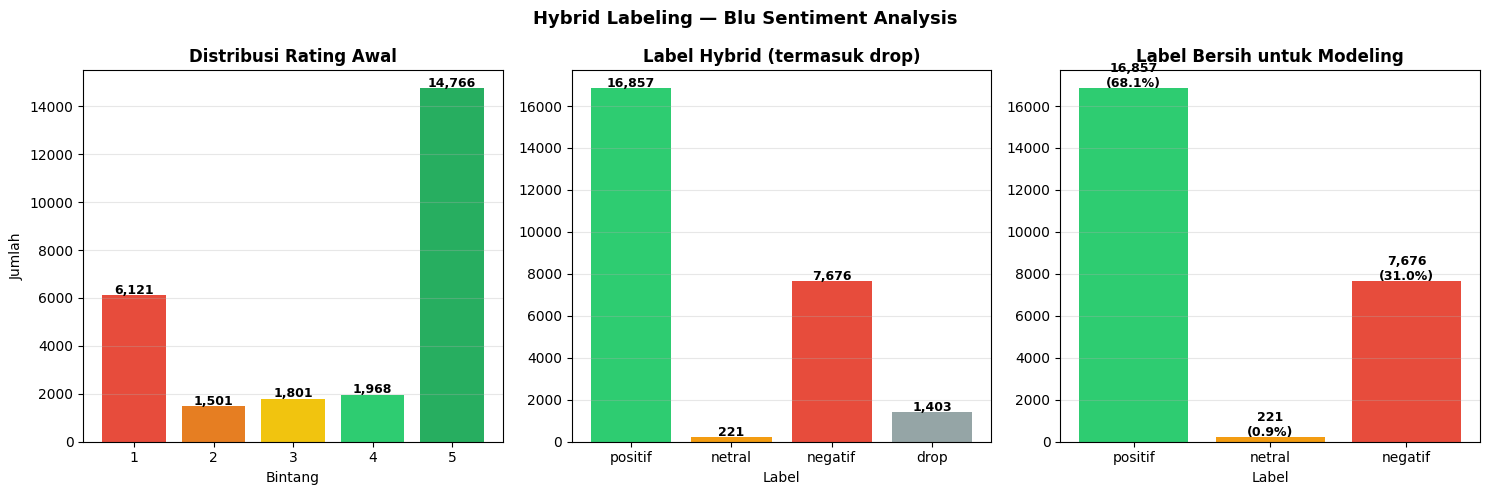

In [ ]:
# Visualisasi sebelum vs sesudah
df_clean = df[df['sentiment'] != 'drop'].copy()

COLORS = {'positif': '#2ECC71', 'negatif': '#E74C3C', 'netral': '#F39C12', 'drop': '#95A5A6'}
ORDER  = ['positif', 'netral', 'negatif']

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Sebelum: distribusi rating
rating_colors = {1:'#E74C3C', 2:'#E67E22', 3:'#F1C40F', 4:'#2ECC71', 5:'#27AE60'}
rc = df[SCORE_COL].value_counts().sort_index()
axes[0].bar(rc.index.astype(str), rc.values,
            color=[rating_colors[r] for r in rc.index])
axes[0].set_title('Distribusi Rating Awal', fontweight='bold')
axes[0].set_xlabel('Bintang')
axes[0].set_ylabel('Jumlah')
for i, (r, v) in enumerate(zip(rc.index, rc.values)):
    axes[0].text(i, v + 50, f'{v:,}', ha='center', fontsize=9, fontweight='bold')

# Distribusi label hasil hybrid (semua, termasuk drop)
all_lbl = df['sentiment'].value_counts()
labels_all  = [l for l in [*ORDER, 'drop'] if l in all_lbl.index]
vals_all    = [all_lbl[l] for l in labels_all]
clrs_all    = [COLORS[l] for l in labels_all]
axes[1].bar(labels_all, vals_all, color=clrs_all)
axes[1].set_title('Label Hybrid (termasuk drop)', fontweight='bold')
axes[1].set_xlabel('Label')
for i, (l, v) in enumerate(zip(labels_all, vals_all)):
    axes[1].text(i, v + 50, f'{v:,}', ha='center', fontsize=9, fontweight='bold')

# Distribusi label bersih (tanpa drop)
clean_lbl   = df_clean['sentiment'].value_counts()
labels_clean = [l for l in ORDER if l in clean_lbl.index]
vals_clean   = [clean_lbl[l] for l in labels_clean]
clrs_clean   = [COLORS[l] for l in labels_clean]
axes[2].bar(labels_clean, vals_clean, color=clrs_clean)
axes[2].set_title('Label Bersih untuk Modeling', fontweight='bold')
axes[2].set_xlabel('Label')
for i, (l, v) in enumerate(zip(labels_clean, vals_clean)):
    axes[2].text(i, v + 50, f'{v:,}\n({v/len(df_clean)*100:.1f}%)',
                 ha='center', fontsize=9, fontweight='bold')

for ax in axes:
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('Hybrid Labeling — Blu Sentiment Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('visualisasi/hybrid_labeling_summary.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Inspeksi Manual — Validasi Sampel

In [22]:
def show_samples(label, method=None, n=8):
    """Tampilkan sampel review untuk validasi manual."""
    mask = df['sentiment'] == label
    if method:
        mask &= df['label_method'] == method
    sample = df[mask].sample(min(n, mask.sum()), random_state=42)
    cols = [SCORE_COL, TEXT_COL, 'sentiment', 'label_method', 'label_reason',
            'pos_count', 'neg_count', 'net_score']
    cols = [c for c in cols if c in sample.columns]
    display(sample[cols].reset_index(drop=True))

print('=== Sampel POSITIF (via rating) ===')
show_samples('positif', method='rating', n=5)

=== Sampel POSITIF (via rating) ===


,score,final_content,sentiment,label_method,label_reason,pos_count,neg_count,net_score
0,5,mudah praktis fiturnya bagus pokok,positif,rating,rating_ekstrem_tinggi,4,0,4
1,5,halo min dev apknya bagus mudah depan tingkat ...,positif,rating,rating_ekstrem_tinggi,3,0,3
2,5,perban baik,positif,rating,teks_pendek_pakai_rating,1,0,1
3,5,aduh berat aplikasi ayo kelas usaha aplikasi,positif,rating,rating_ekstrem_tinggi,0,1,-1
4,5,menu,positif,rating,teks_pendek_pakai_rating,0,0,0


In [23]:
print('=== Sampel NEGATIF (via rating) ===')
show_samples('negatif', method='rating', n=5)

=== Sampel NEGATIF (via rating) ===


,score,final_content,sentiment,label_method,label_reason,pos_count,neg_count,net_score
0,1,lambat lambat lambat,negatif,rating,rating_ekstrem_rendah,0,1,-1
1,1,tolong serius berat banget loading responya la...,negatif,rating,rating_ekstrem_rendah,3,3,0
2,1,download by pasu data masuk nomor kartu atm bc...,negatif,rating,rating_ekstrem_rendah,1,0,1
3,1,transfer kena biaya uninstal guna,negatif,rating,rating_ekstrem_rendah,0,0,0
4,1,eror,negatif,rating,teks_pendek_pakai_rating,0,1,-1


In [24]:
print('=== Sampel rating 3 yang dilabeli via TEKS ===')
show_samples('positif', method='teks', n=4)
show_samples('negatif', method='teks', n=4)

=== Sampel rating 3 yang dilabeli via TEKS ===


,score,final_content,sentiment,label_method,label_reason,pos_count,neg_count,net_score
0,3,bagus sih ganti nomor hubung csnya mudah ganti...,positif,teks,rating3_teks_positif,2,0,2
1,3,bagus gratis tarik tunai kasih bebas biaya adm...,positif,teks,rating3_teks_positif,1,0,1
2,3,bagus up dana ko biaya sih mending dah,positif,teks,rating3_teks_positif,1,0,1
3,3,hape terdekteksi rot buka lancar buka hp origi...,positif,teks,rating3_teks_positif,2,0,2


,score,final_content,sentiment,label_method,label_reason,pos_count,neg_count,net_score
0,3,tingkat performa ngerespon kalo pas d pijit me...,negatif,teks,rating3_teks_negatif,0,1,-1
1,3,kali bagus god job mana butuh atm kartu membia...,negatif,teks,rating3_teks_negatif,2,4,-2
2,3,maf turun bintang versi verifikasi scan wajah ...,negatif,teks,rating3_teks_negatif,0,2,-2
3,3,kl nyimpen uang tarik rek sndr kena biaya hapu...,negatif,teks,rating3_teks_negatif,0,1,-1


In [25]:
print('=== Sampel yang di-DROP ===')
show_samples('drop', n=8)

=== Sampel yang di-DROP ===


,score,final_content,sentiment,label_method,label_reason,pos_count,neg_count,net_score
0,4,kyc ribet kalo koneksi internetnya lemah susah...,drop,drop,konflik_rating_tinggi_teks_negatif,0,2,-2
1,4,susah daftar vidio cal foto ktp kamera dadak k...,drop,drop,konflik_rating_tinggi_teks_negatif,0,2,-2
2,3,coba kali masuk pdhl suruh wawancara,drop,drop,rating3_teks_pendek,0,0,0
3,3,dapet info bikin nomor rekening cantik yaudah ...,drop,drop,rating3_tidak_ada_sinyal,0,0,0
4,3,ko gin yak biaya admin sotor tarik tunai iye t...,drop,drop,rating3_tidak_ada_sinyal,0,0,0
5,3,verivikasi wajah gagal tuh,drop,drop,rating3_teks_pendek,0,1,-1
6,3,si buka berat baget tolong buka,drop,drop,rating3_teks_pendek,0,1,-1
7,4,banget bayar gabisa buka kesel banget huhu sam...,drop,drop,konflik_rating_tinggi_teks_negatif,0,2,-2


## 8. Cek Konflik Rating vs Teks

In [26]:
# Review yang rating dan teks-nya berbeda arah (tidak di-drop)
df_keep = df[df['sentiment'] != 'drop'].copy()

mismatch = df_keep[
    (df_keep['text_label'] != 'netral') &
    (df_keep['sentiment'] != df_keep['text_label'])
].copy()

print(f'Review dengan label berbeda antara rating vs teks: {len(mismatch):,}')
print(f'({len(mismatch)/len(df_keep)*100:.1f}% dari data yang dipakai)\n')

if len(mismatch) > 0:
    print('Contoh (rating dipercaya, teks mengatakan lain):')
    cols_show = [SCORE_COL, TEXT_COL, 'sentiment', 'text_label', 'pos_count', 'neg_count']
    cols_show = [c for c in cols_show if c in mismatch.columns]
    display(mismatch[cols_show].head(10))

Review dengan label berbeda antara rating vs teks: 1,594
(6.4% dari data yang dipakai)

Contoh (rating dipercaya, teks mengatakan lain):


,score,final_content,sentiment,text_label,pos_count,neg_count
4,1,kocak verifikasi wajah blokir lawak,negatif,positif,1,0
15,1,terima kasih layan muas,negatif,positif,1,0
28,1,coba tarik tunai setor tunai indomaret gitu ke...,negatif,positif,1,0
35,5,plis lambat lambat aplikasi sebel kasih bintan...,positif,negatif,0,1
47,2,tawar pnjaman gilir aju diac hpus aj mnding sh...,negatif,positif,1,0
57,4,lambat kadang,positif,negatif,0,1
68,5,aduh berat aplikasi ayo kelas usaha aplikasi,positif,negatif,0,1
88,5,bug transaksi hasil si terima terima,positif,negatif,0,1
124,2,baik bug log in baik lancar transaksi tolong m...,negatif,positif,2,1
137,5,upgrad masuk ribet gimanatransaksi adminya mahal,positif,negatif,0,1


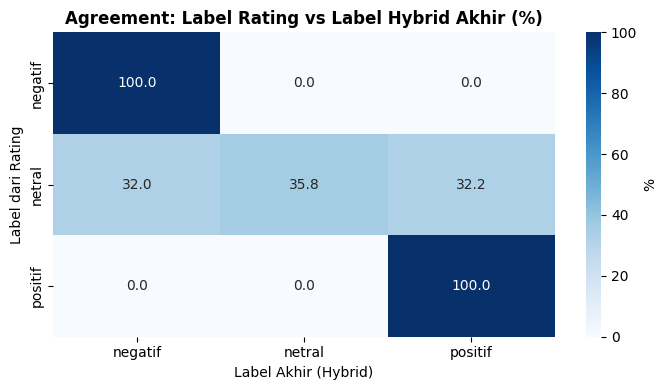


Overall agreement rating vs label hybrid: 98.4%


In [ ]:
# Heatmap agreement rating vs label akhir
df_keep['rating_label'] = df_keep[SCORE_COL].apply(get_rating_label)
agreement = pd.crosstab(df_keep['rating_label'], df_keep['sentiment'],
                        normalize='index') * 100

plt.figure(figsize=(7, 4))
sns.heatmap(agreement, annot=True, fmt='.1f', cmap='Blues',
            cbar_kws={'label': '%'})
plt.title('Agreement: Label Rating vs Label Hybrid Akhir (%)', fontweight='bold')
plt.xlabel('Label Akhir (Hybrid)')
plt.ylabel('Label dari Rating')
plt.tight_layout()
plt.savefig('visualisasi/label_agreement_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

overall_agree = (df_keep['rating_label'] == df_keep['sentiment']).mean() * 100
print(f'\nOverall agreement rating vs label hybrid: {overall_agree:.1f}%')

## 9. Opsi Tambahan: Klasifikasi Binary (tanpa netral)

In [28]:
# Binary = lebih simpel, F1 biasanya lebih tinggi
# Drop netral → hanya positif vs negatif

df_binary = df_keep[df_keep['sentiment'].isin(['positif', 'negatif'])].copy()

n_pos = (df_binary['sentiment'] == 'positif').sum()
n_neg = (df_binary['sentiment'] == 'negatif').sum()

print('Opsi Binary Classification (positif vs negatif):')
print(f'  Positif : {n_pos:,} ({n_pos/len(df_binary)*100:.1f}%)')
print(f'  Negatif : {n_neg:,} ({n_neg/len(df_binary)*100:.1f}%)')
print(f'  Total   : {len(df_binary):,}')
print()
print('Rekomendasi:')
ratio = max(n_pos, n_neg) / min(n_pos, n_neg)
if ratio > 3:
    print(f'  ⚠️  Imbalance tinggi ({ratio:.1f}x). Pertimbangkan SMOTE atau class_weight="balanced".')
else:
    print(f'  ✅ Distribusi relatif seimbang ({ratio:.1f}x). Siap untuk training.')

Opsi Binary Classification (positif vs negatif):
  Positif : 16,857 (68.7%)
  Negatif : 7,676 (31.3%)
  Total   : 24,533

Rekomendasi:
  ✅ Distribusi relatif seimbang (2.2x). Siap untuk training.


## 10. Simpan Output

In [29]:
import os
os.makedirs('../data', exist_ok=True)

# ── Dataset bersih (3 kelas: positif, netral, negatif)
df_keep.to_csv(OUTPUT_PATH, index=False)
print(f'✅ Dataset 3-kelas disimpan  : {OUTPUT_PATH}')
print(f'   Shape: {df_keep.shape}')

# ── Dataset binary (positif vs negatif)
binary_path = OUTPUT_PATH.replace('.csv', '_binary.csv')
df_binary.to_csv(binary_path, index=False)
print(f'✅ Dataset binary disimpan   : {binary_path}')
print(f'   Shape: {df_binary.shape}')

# ── Dataset lengkap dengan semua metadata (termasuk drop)
full_path = OUTPUT_PATH.replace('.csv', '_with_drop.csv')
df.to_csv(full_path, index=False)
print(f'✅ Dataset lengkap (+drop)   : {full_path}')
print(f'   Shape: {df.shape}')

✅ Dataset 3-kelas disimpan  : ../data/bluapp_reviews_labeled.csv
   Shape: (24754, 16)
✅ Dataset binary disimpan   : ../data/bluapp_reviews_labeled_binary.csv
   Shape: (24533, 16)
✅ Dataset lengkap (+drop)   : ../data/bluapp_reviews_labeled_with_drop.csv
   Shape: (26157, 15)


In [30]:
# Ringkasan akhir
print('\n' + '='*55)
print('  RINGKASAN AKHIR')
print('='*55)
print(f'  Data masuk          : {total:>8,}')
print(f'  Di-drop (noise)     : {n_drop:>8,} ({n_drop/total*100:.1f}%)')
print(f'  Dataset 3-kelas     : {len(df_keep):>8,} ({len(df_keep)/total*100:.1f}%)')
print(f'  Dataset binary      : {len(df_binary):>8,} ({len(df_binary)/total*100:.1f}%)')
print('='*55)
print()
print('File output tersimpan di folder ../data/')
print()
print('Langkah berikutnya:')
print('  → Jalankan data_export_helper.ipynb (update path ke blu_hybrid_labeled.csv)')
print('  → Jalankan Modeling/modeling.ipynb')


  RINGKASAN AKHIR
  Data masuk          :   26,157
  Di-drop (noise)     :    1,403 (5.4%)
  Dataset 3-kelas     :   24,754 (94.6%)
  Dataset binary      :   24,533 (93.8%)

File output tersimpan di folder ../data/

Langkah berikutnya:
  → Jalankan data_export_helper.ipynb (update path ke blu_hybrid_labeled.csv)
  → Jalankan Modeling/modeling.ipynb
